In [1]:
# Install dependencies
!pip install -U transformers accelerate bitsandbytes pillow numpy pandas scikit-image opencv-python tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-a8ciaqfz
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-a8ciaqfz
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=ffc67699e39a6d9a4d31e380a17622ba7e6c0197c6a55b96bdc06d28707ffb0c
  Stored in directory: /tmp/pip-ephem-wheel-cache-h82ercg9/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [2]:
!git clone https://github.com/bowang-lab/MedSAM.git

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 29.11 MiB/s, done.
Resolving deltas: 100% (475/475), done.


In [3]:
%cd MedSAM

/content/MedSAM


In [4]:
!pip install -e .

Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.3 MB/s eta 0:00:00
  Running setup.py develop for medsam


In [5]:
%cd ..

!unzip Datasets.zip -d datasets

/content
Archive:  Datasets.zip
  inflating: datasets/Datasets/CVC-ClinicDB/test/masks/29.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/14.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/18.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/30.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/1.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/26.jpg  
  inflating: datasets/Datasets/Kvasir-SEG/test/masks/30.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/17.jpg  
  inflating: datasets/Datasets/CVC-ClinicDB/test/images/2.jpg  
  inflating: datasets/Datasets/CVC-ClinicDB/test/masks/39.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/37.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/2.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/9.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/5.jpg  
  inflating: datasets/Datasets/Kva

In [6]:
!mv datasets/Datasets/ .

In [7]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")  # or replace with your token string
login(hf_token)
print("HF login done")

HF login done


In [8]:
# Results
OUTPUT_DIR = "/content/polyp_medgemma_medsam_results"

# Put your MedSAM checkpoint here
MEDSAM_CKPT = "/content/medsam_vit_b.pth"

# MedGemma model
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"

# Datasets
DATASET_DIRS = [
    "/content/Datasets/CVC-ClinicDB",
    "/content/Datasets/CVC-ColonDB",
    "/content/Datasets/ETIS-LaribPolypDB",
    "/content/Datasets/Kvasir-SEG"
]

In [9]:
!pwd

/content


In [10]:
# RETRIEVAL
import os
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import (
    AutoProcessor,
    AutoModel,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
)

In [11]:
# Folder containing the retrieval database images
IMAGE_FOLDER = "/content/Datasets/CVC-ClinicDB/train/images"

# Query image path
QUERY_IMAGE = "/content/Datasets/CVC-ClinicDB/train/images/0.jpg"
# Where to save index files
INDEX_CSV = "/content/retrieval_index.csv"
EMBED_NPY = "/content/retrieval_embeddings.npy"

# Embedding model for retrieval
RETRIEVAL_MODEL_ID = "google/medsiglip-448"

# Explanation model
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"

In [12]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_images_recursive(folder):
    folder = Path(folder)
    files = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            files.append(str(p))
    return sorted(files)

def open_rgb(path):
    return Image.open(path).convert("RGB")

def get_image_embedding(model, processor, image_path, device):
    img = open_rgb(image_path)
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.get_image_features(**inputs)

    if isinstance(out, torch.Tensor):
        emb = out.detach().cpu().numpy().squeeze()
    elif hasattr(out, "image_embeds") and out.image_embeds is not None:
        emb = out.image_embeds.detach().cpu().numpy().squeeze()
    elif hasattr(out, "pooler_output") and out.pooler_output is not None:
        emb = out.pooler_output.detach().cpu().numpy().squeeze()
    else:
        emb = out.last_hidden_state[:, 0].detach().cpu().numpy().squeeze()

    emb = emb.astype(np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return emb

def show_results(query_path, results, cols=3, figsize=(16, 8)):
    n = len(results) + 1
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)

    plt.subplot(rows, cols, 1)
    plt.imshow(open_rgb(query_path))
    plt.title("Query")
    plt.axis("off")

    for i, item in enumerate(results, start=2):
        plt.subplot(rows, cols, i)
        plt.imshow(open_rgb(item["image_path"]))
        plt.title(f"Rank {item['rank']}\nSim={item['similarity']:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
def build_retrieval_index(
    image_folder,
    model_id="google/medsiglip-448",
    index_csv="/content/retrieval_index.csv",
    embed_npy="/content/retrieval_embeddings.npy",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    image_paths = list_images_recursive(image_folder)
    print("Found images:", len(image_paths))

    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    rows = []
    embeds = []

    for img_path in tqdm(image_paths, desc="Indexing"):
        try:
            emb = get_image_embedding(model, processor, img_path, device)
            embeds.append(emb)
            rows.append({
                "image_path": img_path,
                "image_name": os.path.basename(img_path),
            })
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    if len(embeds) == 0:
        raise ValueError("No embeddings created.")

    embeddings = np.vstack(embeds)
    index_df = pd.DataFrame(rows)

    np.save(embed_npy, embeddings)
    index_df.to_csv(index_csv, index=False)

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Saved:", index_csv, embed_npy)
    return index_df, embeddings

In [14]:
index_df, embeddings = build_retrieval_index(
    image_folder=IMAGE_FOLDER,
    model_id=RETRIEVAL_MODEL_ID,
    index_csv=INDEX_CSV,
    embed_npy=EMBED_NPY,
)

Device: cuda
Found images: 488


preprocessor_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Indexing: 100%|██████████| 488/488 [02:25<00:00,  3.36it/s]


Saved: /content/retrieval_index.csv /content/retrieval_embeddings.npy


In [15]:
def retrieve_similar_images(
    query_image_path,
    index_csv="/content/retrieval_index.csv",
    embed_npy="/content/retrieval_embeddings.npy",
    model_id="google/medsiglip-448",
    top_k=5,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    index_df = pd.read_csv(index_csv)
    embeddings = np.load(embed_npy)

    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    query_emb = get_image_embedding(model, processor, query_image_path, device)
    sims = cosine_similarity([query_emb], embeddings)[0]

    order = np.argsort(sims)[::-1]

    results = []
    rank = 1
    query_abs = os.path.abspath(query_image_path)

    for idx in order:
        candidate_path = index_df.iloc[idx]["image_path"]
        if os.path.abspath(candidate_path) == query_abs:
            continue

        results.append({
            "rank": rank,
            "image_path": candidate_path,
            "image_name": index_df.iloc[idx]["image_name"],
            "similarity": float(sims[idx]),
        })
        rank += 1

        if len(results) >= top_k:
            break

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

In [16]:
results = retrieve_similar_images(
    query_image_path=QUERY_IMAGE,
    index_csv=INDEX_CSV,
    embed_npy=EMBED_NPY,
    model_id=RETRIEVAL_MODEL_ID,
    top_k=5,
)

pd.DataFrame(results)

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

,rank,image_path,image_name,similarity
0,1,/content/Datasets/CVC-ClinicDB/train/images/45...,451.jpg,0.952051
1,2,/content/Datasets/CVC-ClinicDB/train/images/14...,143.jpg,0.951738
2,3,/content/Datasets/CVC-ClinicDB/train/images/30...,304.jpg,0.937090
3,4,/content/Datasets/CVC-ClinicDB/train/images/29...,292.jpg,0.932486
4,5,/content/Datasets/CVC-ClinicDB/train/images/15...,158.jpg,0.929468


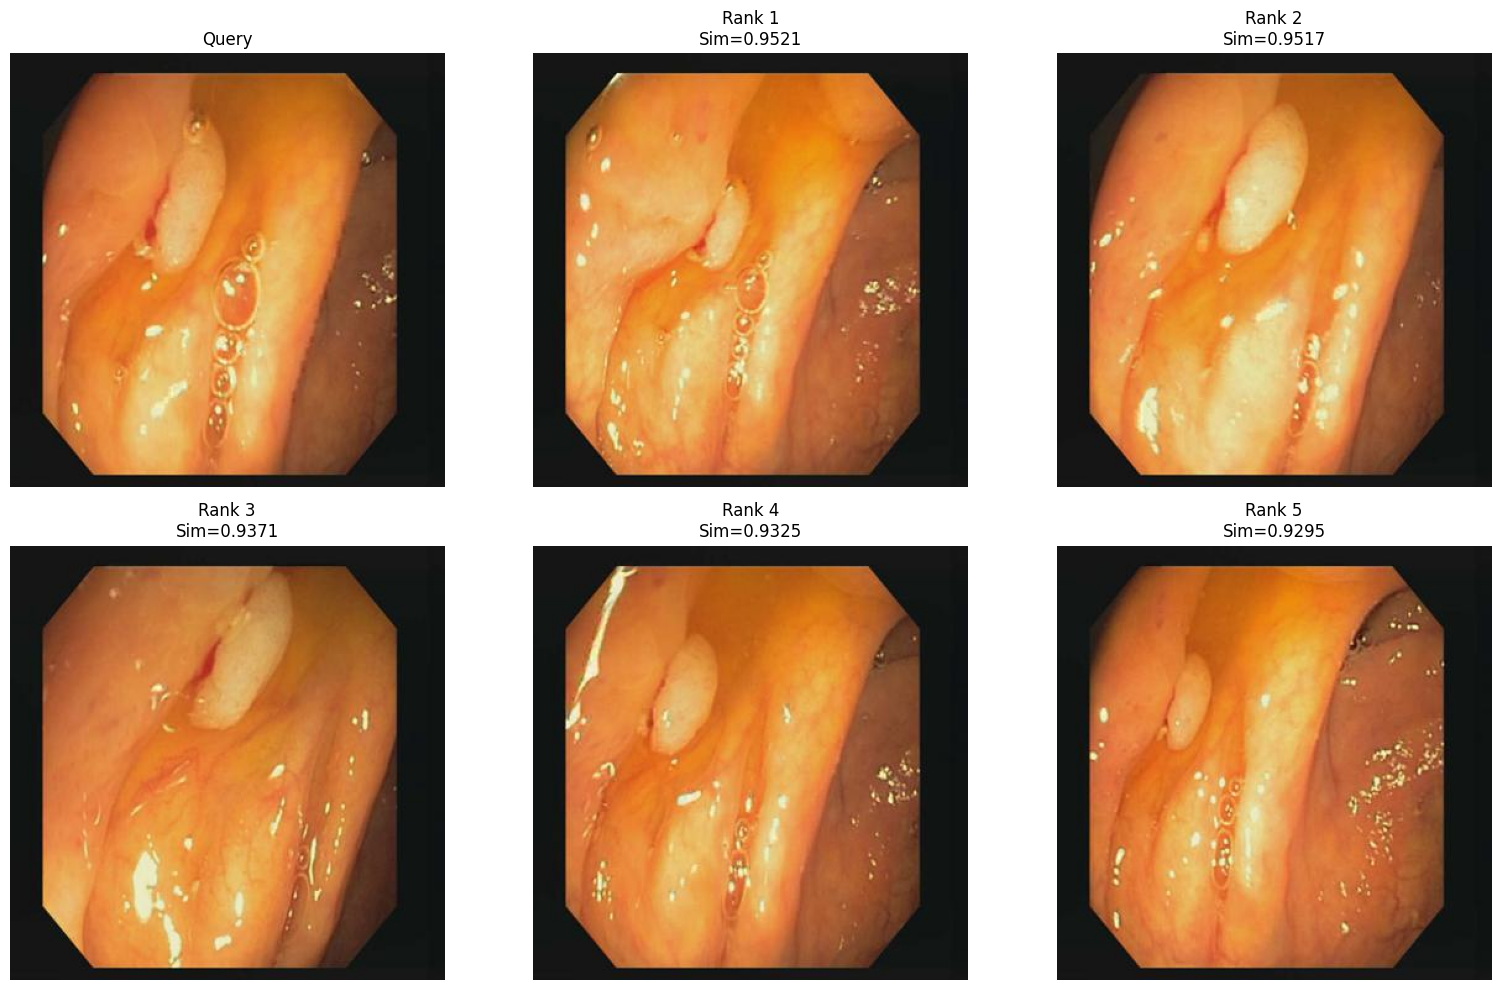

In [17]:
show_results(QUERY_IMAGE, results, cols=3, figsize=(16, 10))

In [18]:
class MedGemmaSimilarityExplainer:
    def __init__(self, model_id="google/medgemma-4b-it", use_4bit=True):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        if use_4bit:
            bnb = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id,
                quantization_config=bnb,
                device_map="auto",
            )
        else:
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None,
            )

        self.processor = AutoProcessor.from_pretrained(model_id)

    @torch.inference_mode()
    def explain_pair(self, query_image_path, retrieved_image_path):
        query_img = open_rgb(query_image_path)
        retrieved_img = open_rgb(retrieved_image_path)

        prompt = (
            "You are a medical imaging assistant.\n"
            "Compare these two endoscopic or colonoscopy images.\n"
            "Explain briefly why they are medically similar.\n"
            "Focus on visible features such as:\n"
            "- polyp presence\n"
            "- shape\n"
            "- border\n"
            "- color\n"
            "- texture\n"
            "- protrusion\n"
            "- mucosal pattern\n"
            "Give a short educational explanation in 3 to 5 sentences.\n"
            "Do not diagnose with certainty. Say 'may be consistent with' when needed."
        )

        messages = [{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": query_img},
                {"type": "image", "image": retrieved_img},
            ],
        }]

        inputs = self.processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )

        inputs = {k: v.to(self.model.device) if hasattr(v, "to") else v for k, v in inputs.items()}

        output = self.model.generate(
            **inputs,
            max_new_tokens=180,
            do_sample=False,
        )

        response = self.processor.decode(
            output[0][inputs["input_ids"].shape[-1]:],
            skip_special_tokens=True,
        )
        return response.strip()

In [19]:
explainer = MedGemmaSimilarityExplainer(
    model_id=MEDGEMMA_MODEL_ID,
    use_4bit=True,
)

for item in results:
    reason = explainer.explain_pair(QUERY_IMAGE, item["image_path"])
    item["medical_reason"] = reason
    print(f"\nRank {item['rank']} | {item['image_name']} | sim={item['similarity']:.4f}")
    print(reason)
    print("-" * 100)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]


Rank 1 | 451.jpg | sim=0.9521
Based on the provided images, both show a polyp. The polyp appears to be a raised, irregular mass protruding from the mucosal surface. The color and texture of the polyp are similar in both images.

The polyp may be consistent with a benign growth. Further evaluation by a gastroenterologist is needed to confirm the diagnosis and rule out malignancy.
----------------------------------------------------------------------------------------------------

Rank 2 | 143.jpg | sim=0.9517
Here's a comparison of the two images, focusing on visible features:

**Image 1:**

*   **Polyp:** The image shows a few polyps.
*   **Shape:** The polyps appear to be somewhat irregular in shape.
*   **Border:** The borders of the polyps are not clearly defined.
*   **Color:** The color of the polyps is yellowish.
*   **Texture:** The texture of the polyps is somewhat rough.
*   **Protrusion:** The polyps are protruding from the mucosa.
*   **Mucosal Pattern:** The mucosal patter

In [20]:
df_results = pd.DataFrame(results)
df_results

,rank,image_path,image_name,similarity,medical_reason
0,1,/content/Datasets/CVC-ClinicDB/train/images/45...,451.jpg,0.952051,"Based on the provided images, both show a poly..."
1,2,/content/Datasets/CVC-ClinicDB/train/images/14...,143.jpg,0.951738,"Here's a comparison of the two images, focusin..."
2,3,/content/Datasets/CVC-ClinicDB/train/images/30...,304.jpg,0.937090,"Based on the provided images, both show a poly..."
3,4,/content/Datasets/CVC-ClinicDB/train/images/29...,292.jpg,0.932486,"Based on the provided images, both show a poly..."
4,5,/content/Datasets/CVC-ClinicDB/train/images/15...,158.jpg,0.929468,"Based on the images, both show a polyp. The po..."


In [21]:
SAVE_CSV = "/content/retrieval_with_medical_reasons.csv"
df_results.to_csv(SAVE_CSV, index=False)
print("Saved to:", SAVE_CSV)

Saved to: /content/retrieval_with_medical_reasons.csv


In [22]:
!pip install scikit-learn seaborn

In [33]:
from sklearn.manifold import TSNE
import seaborn as sns

def visualize_tsne(
    index_csv,
    embed_npy,
    query_image_path=None,
    retrieved_results=None,
    perplexity=30,
    random_state=42,
):
    """
    Visualize embedding space using t-SNE.
    Optionally highlight query and retrieved images.
    """

    index_df = pd.read_csv(index_csv)
    embeddings = np.load(embed_npy)

    print("Running t-SNE on embeddings:", embeddings.shape)

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, len(embeddings) - 1),
        random_state=random_state,
        init="random",
        learning_rate="auto"
    )

    reduced = tsne.fit_transform(embeddings)

    index_df["tsne_x"] = reduced[:, 0]
    index_df["tsne_y"] = reduced[:, 1]

    plt.figure(figsize=(10, 10))

    # base scatter
    sns.scatterplot(
        x="tsne_x",
        y="tsne_y",
        data=index_df,
        s=40,
        color="lightgray",
        alpha=0.7,
        label="Dataset image embeddings"
    )

    # highlight query
    if query_image_path is not None:
        query_match = index_df[index_df["image_path"] == query_image_path]

        if len(query_match) > 0:
            plt.scatter(
                query_match["tsne_x"],
                query_match["tsne_y"],
                c="red",
                s=50,
                label="Query image embeddings",
                marker="X"
            )

    # highlight retrieved
    if retrieved_results is not None:
        retrieved_paths = [r["image_path"] for r in retrieved_results]

        retrieved_df = index_df[index_df["image_path"].isin(retrieved_paths)]

        plt.scatter(
            retrieved_df["tsne_x"],
            retrieved_df["tsne_y"],
            c="blue",
            s=50,
            label="Retrieved image embeddings",
            marker="o"
        )

    plt.title("t-SNE Visualization of Image Embeddings")
    plt.xlabel("Latent Medical Image Feature Space (t-SNE Dim 1)")
    plt.ylabel("Latent Medical Image Feature Space (t-SNE Dim 2)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return index_df

Running t-SNE on embeddings: (488, 1152)


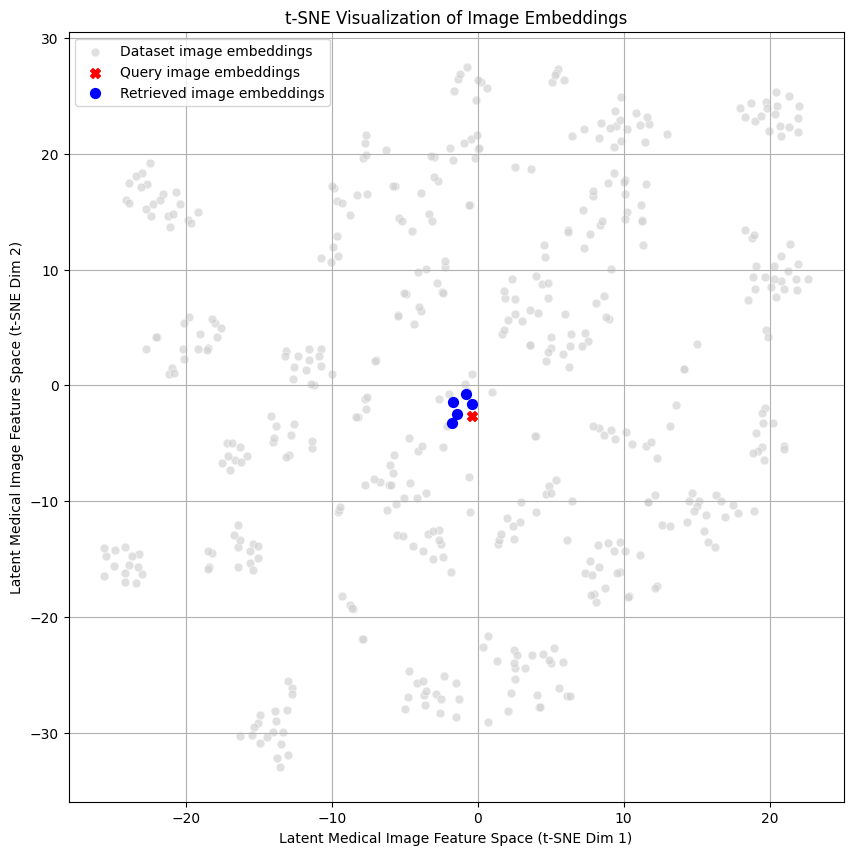

In [34]:
tsne_df = visualize_tsne(
    index_csv=INDEX_CSV,
    embed_npy=EMBED_NPY,
    query_image_path=QUERY_IMAGE,
    retrieved_results=results,
)